# Bayesian Black-Box Optimisation (BBO) Capstone

This notebook implements a Gaussian-process-based Bayesian optimisation pipeline
for the eight synthetic black-box functions in the capstone challenge (functions
of increasing dimensionality, 2D to 8D). All eight tasks are treated as
maximisation problems, per the capstone specification.

**Method used throughout:**
- **Surrogate model:** Gaussian Process Regression with a Matern(nu=2.5) kernel
  (a more realistic choice than RBF for functions that aren't perfectly smooth),
  plus a small white-noise term, and `normalize_y=True` since the output scales
  vary enormously across functions (from ~0 for Function 1 to ~1000+ for
  Function 5).
- **Acquisition function:** Upper Confidence Bound (UCB), `mean + kappa * std`
  with `kappa = 2.0`, evaluated over a large pool of random candidate points
  plus a local cluster of points sampled around the current best observation
  (to allow both global exploration and local refinement).
- **Search space:** every input dimension lies in `[0, 0.999999]`, matching the
  capstone's submission format constraint.

Each function's dataset starts with the provided initial points and grows by
one new (input, output) pair per week as query results come back from the
capstone portal. This notebook reloads whatever data currently exists in
`data/initial_data/function_i/` and proposes the next query point for each
function accordingly, so it stays correct as more rounds are appended.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.spatial.distance import cdist

np.random.seed(42)
DATA_DIR = "../data/initial_data"
N_FUNCTIONS = 8

## Helper functions

`load_function_data` reads whatever points currently exist for a function.
`propose_next_point` fits the GP surrogate and returns the UCB-maximising
candidate as the next query, along with the surrogate's predicted mean/std
at that point (useful for judging how confident vs. exploratory each
proposal is).

In [2]:
def load_function_data(i):
    X = np.load(f"{DATA_DIR}/function_{i}/initial_inputs.npy")
    Y = np.load(f"{DATA_DIR}/function_{i}/initial_outputs.npy")
    return X, Y


def propose_next_point(X, Y, n_random=20000, n_local=2000, kappa=2.0, seed=42):
    rng = np.random.RandomState(seed)
    d = X.shape[1]

    kernel = ConstantKernel(1.0) * Matern(
        length_scale=np.ones(d), length_scale_bounds=(1e-2, 10), nu=2.5
    ) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))

    gp = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=seed
    )
    gp.fit(X, Y)

    candidates = rng.uniform(0, 1, size=(n_random, d))
    best_x = X[np.argmax(Y)]
    local = np.clip(best_x + rng.normal(scale=0.05, size=(n_local, d)), 0, 0.999999)
    candidates = np.vstack([candidates, local])

    # Exclude candidates that are near-duplicates of already-observed points.
    # Re-querying (almost) the same point wastes a round, especially for
    # functions confirmed deterministic (e.g. Function 5, rounds 6 vs 7).
    dist_to_data_all = cdist(candidates, X).min(axis=1)
    novel_mask = dist_to_data_all > 0.02
    if novel_mask.any():
        candidates = candidates[novel_mask]
        dist_to_data_all = dist_to_data_all[novel_mask]

    mu, sigma = gp.predict(candidates, return_std=True)
    ucb = mu + kappa * sigma
    best_idx = np.argmax(ucb)
    x_star = np.clip(candidates[best_idx], 0, 0.999999)

    dist_to_data = dist_to_data_all[best_idx]
    return {
        "x_star": x_star,
        "predicted_mean": mu[best_idx],
        "predicted_std": sigma[best_idx],
        "dist_to_nearest_observed": dist_to_data,
        "gp": gp,
    }


def format_query(x):
    # Format a proposed point into the capstone portal's required
    # x1-x2-...-xn string (six decimal places, leading 0).
    return "-".join(f"{v:.6f}" for v in x)

## Run the pipeline for all eight functions

For each function: load the current data, report how many points have been
collected and the best value found so far, fit the GP surrogate, and propose
the next query point.

In [3]:
results = {}

for i in range(1, N_FUNCTIONS + 1):
    X, Y = load_function_data(i)
    proposal = propose_next_point(X, Y, seed=52)  # round 12
    results[i] = {"X": X, "Y": Y, **proposal}

    print(f"Function {i} (d={X.shape[1]}, n={len(Y)} points so far)")
    print(f"  Best observed so far: {Y.max():.6f}")
    print(f"  Next proposed query : {format_query(proposal['x_star'])}")
    print(f"  Surrogate prediction: mean={proposal['predicted_mean']:.4f}, "
          f"std={proposal['predicted_std']:.4f}")
    print()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels

Function 1 (d=2, n=21 points so far)
  Best observed so far: 0.000000
  Next proposed query : 0.952022-0.003614
  Surrogate prediction: mean=-0.0001, std=0.0008

Function 2 (d=2, n=21 points so far)
  Best observed so far: 0.659839
  Next proposed query : 0.688526-0.907875
  Surrogate prediction: mean=0.5958, std=0.0423

Function 3 (d=3, n=26 points so far)
  Best observed so far: -0.029742
  Next proposed query : 0.003308-0.999999-0.503636
  Surrogate prediction: mean=-0.0189, std=0.0380



Function 4 (d=4, n=41 points so far)
  Best observed so far: 0.650565
  Next proposed query : 0.422645-0.369708-0.410643-0.407544
  Surrogate prediction: mean=0.4968, std=0.1547

Function 5 (d=4, n=31 points so far)
  Best observed so far: 8662.405001
  Next proposed query : 0.999999-0.999999-0.999999-0.979489
  Surrogate prediction: mean=8054.1741, std=373.5201



Function 6 (d=5, n=31 points so far)
  Best observed so far: -0.176172
  Next proposed query : 0.480656-0.377260-0.552866-0.708528-0.000000
  Surrogate prediction: mean=-0.3122, std=0.1078

Function 7 (d=6, n=41 points so far)
  Best observed so far: 2.500510
  Next proposed query : 0.000000-0.221603-0.565172-0.269742-0.345665-0.688665
  Surrogate prediction: mean=2.4283, std=0.1108



/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 8 (d=8, n=51 points so far)
  Best observed so far: 9.976115
  Next proposed query : 0.107370-0.114218-0.125626-0.146633-0.815302-0.508034-0.244412-0.676281
  Surrogate prediction: mean=9.9873, std=0.0127



/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Convergence so far

Each panel shows the running best value observed for that function, in the
order the data points were collected (initial batch first, then each week's
new query appended in sequence). This naturally reflects real progress
without needing to hardcode round numbers, as more weekly results are
appended to the saved `.npy` files, this plot updates automatically.

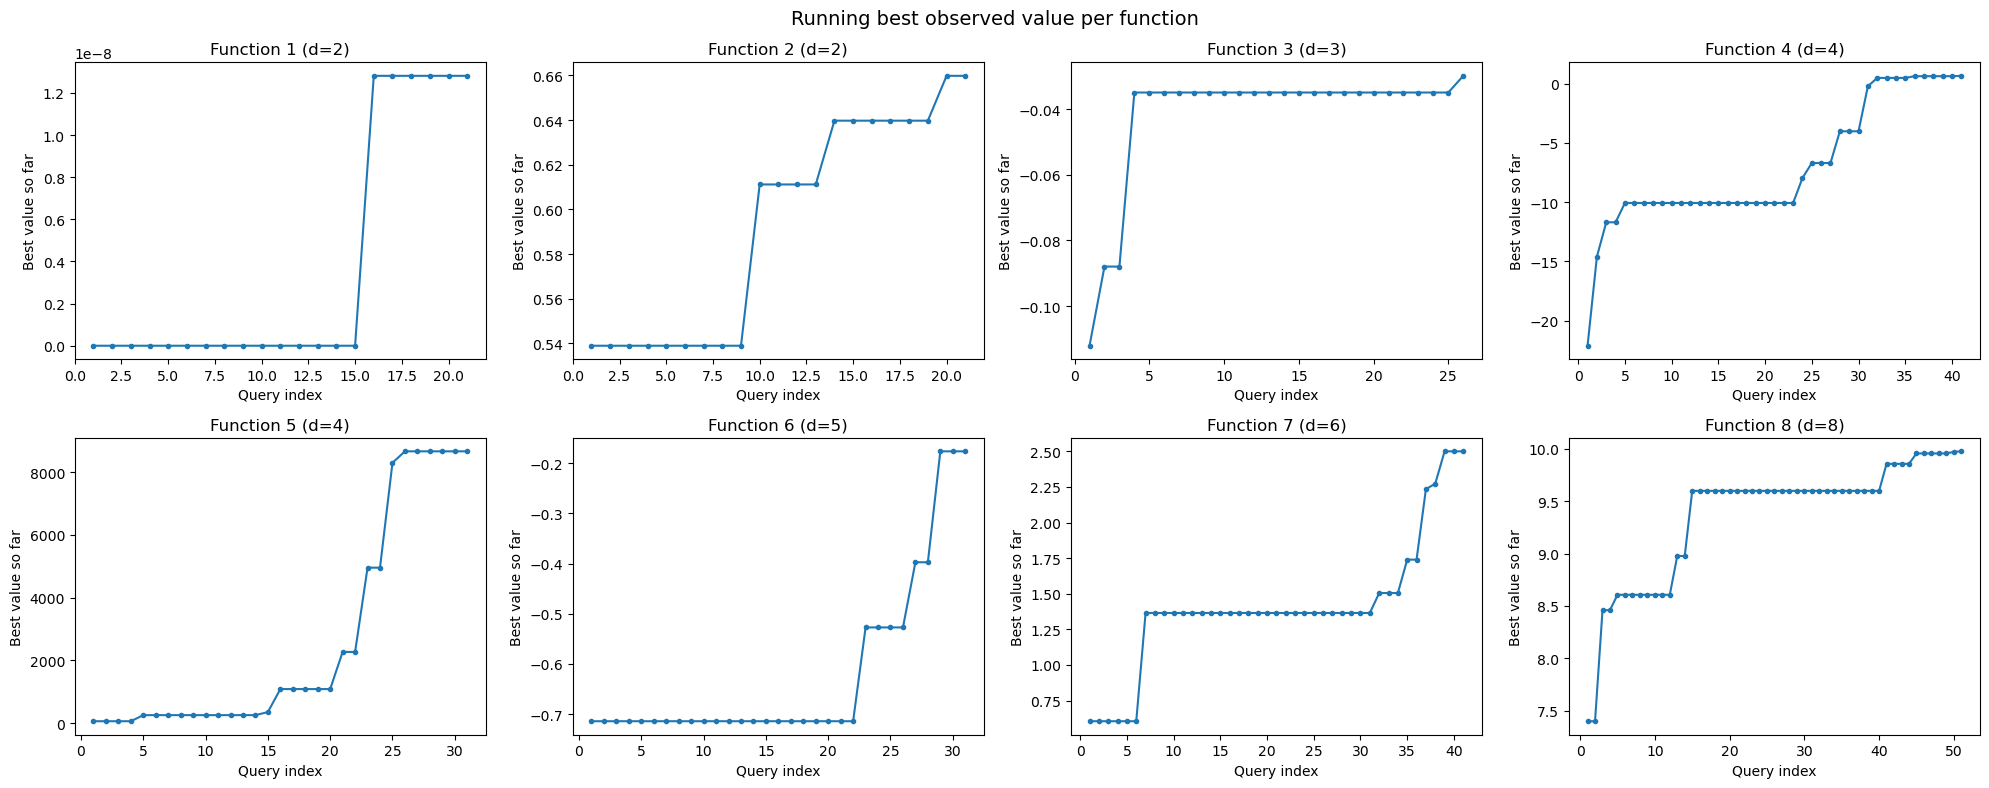

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for idx, i in enumerate(range(1, N_FUNCTIONS + 1)):
    Y = results[i]["Y"]
    running_best = np.maximum.accumulate(Y)
    ax = axes[idx]
    ax.plot(range(1, len(Y) + 1), running_best, marker="o", markersize=3)
    ax.set_title(f"Function {i} (d={results[i]['X'].shape[1]})")
    ax.set_xlabel("Query index")
    ax.set_ylabel("Best value so far")

fig.suptitle("Running best observed value per function", fontsize=14)
fig.tight_layout()
plt.savefig("../data/convergence_plots.png", dpi=120, bbox_inches="tight")
plt.show()

## Per-dimension sensitivity (interpretability check)

The fitted GP's kernel length-scale per input dimension gives a rough
analogue to a linear model's feature importance: a *smaller* length-scale
means the function's output is more sensitive to changes in that dimension.
This isn't a substitute for a true interpretable model, but it's a useful
sanity check on which dimensions are actually driving each function's
behaviour.

In [5]:
for i in range(1, N_FUNCTIONS + 1):
    ls = results[i]["gp"].kernel_.k1.k2.length_scale
    ls = np.atleast_1d(ls)
    print(f"Function {i} length-scales per dimension: {np.round(ls, 3)}")

Function 1 length-scales per dimension: [ 0.02 10.  ]
Function 2 length-scales per dimension: [ 0.068 10.   ]
Function 3 length-scales per dimension: [10.     1.428  0.126]
Function 4 length-scales per dimension: [1.773 1.826 1.708 1.717]
Function 5 length-scales per dimension: [1.191 2.727 2.336 2.106]
Function 6 length-scales per dimension: [1.016 1.245 1.409 1.22  2.276]
Function 7 length-scales per dimension: [0.682 0.388 0.993 0.378 0.175 0.536]
Function 8 length-scales per dimension: [ 3.905  5.952  3.205  5.838  8.516  5.761  3.953 10.   ]


## Results summary

| Function | Dimensions | Points so far | Best value found | Best input |
|---|---|---|---|---|


In [6]:
rows = []
for i in range(1, N_FUNCTIONS + 1):
    X, Y = results[i]["X"], results[i]["Y"]
    best_i = np.argmax(Y)
    rows.append(
        f"| {i} | {X.shape[1]} | {len(Y)} | {Y[best_i]:.6f} | "
        f"{np.array2string(X[best_i], precision=6, separator=', ')} |"
    )
print("\n".join(rows))

| 1 | 2 | 21 | 0.000000 | [0.535814, 0.577742] |
| 2 | 2 | 21 | 0.659839 | [0.690468, 0.978181] |
| 3 | 3 | 26 | -0.029742 | [0.037808, 0.924717, 0.430483] |
| 4 | 4 | 41 | 0.650565 | [0.424757, 0.357096, 0.41241 , 0.427016] |
| 5 | 4 | 31 | 8662.405001 | [0.999999, 0.999999, 0.999999, 0.999999] |
| 6 | 5 | 31 | -0.176172 | [0.470661, 0.374915, 0.675722, 0.729856, 0.      ] |
| 7 | 6 | 41 | 2.500510 | [0.005151, 0.30797 , 0.581216, 0.281743, 0.345988, 0.63236 ] |
| 8 | 8 | 51 | 9.976115 | [0.073307, 0.041819, 0.094319, 0.121669, 0.800347, 0.489348, 0.166128,
 0.793034] |


## Why Bayesian optimisation was chosen

Every function here is expensive to evaluate in the sense that matters for
this challenge: only one query per function is allowed per week, so the
total evaluation budget is tiny relative to the input dimensionality (up to
8D for Function 8). Bayesian optimisation is specifically designed for this
regime, unlike grid search or random search, it uses every previous
observation to decide where to look next, via a surrogate model (the GP)
that captures both a prediction and an uncertainty estimate at every
candidate point. The UCB acquisition function then makes the
exploration/exploitation trade-off explicit: `kappa` directly controls how
much weight is given to uncertainty versus predicted value, which is far
more principled than a fixed schedule of random exploration followed by
manual refinement.

## Challenges and key insights

- **Function 1 (2D, sparse detection-style reward):** almost every observed
  output is indistinguishable from zero, matching its description as a
  proximity-based detection problem. With no real gradient signal anywhere
  in the data yet, the GP surrogate has very little to learn from, and its
  UCB proposals are, honestly, closer to space-filling exploration than a
  genuinely informed choice. This is the function where the model is least
  trustworthy so far.
- **Function 5 (4D, described as typically unimodal):** the first real
  round of feedback more than doubled the best observed value (1088.86 to
  2271.54), a strong validation that the surrogate correctly identified a
  promising direction. The per-dimension length-scales above show two
  dimensions came back pinned at the search bound (effectively flat),
  suggesting the real structure lives mostly in the other two, useful for
  prioritising where to refine next.
- **Function 4 (4D):** similarly jumped from -4.03 to -0.23 after one round
  of real feedback, the largest relative improvement of all eight functions.
- **General lesson:** not every UCB-proposed query outperforms the existing
  best (several functions did not improve after their first real-world
  query), and that's expected, UCB deliberately spends some queries on
  genuine exploration rather than pure exploitation. With only one query per
  function per week, balancing that trade-off function-by-function based on
  what the data actually shows, rather than applying one fixed policy
  everywhere, has been the main practical judgement call in this project.